In [1]:
import sys
import torch
sys.path.append("/global/u1/r/rmastand/mlpf-ssl/particlemind")
#!{sys.executable} -m pip install awkward

import os

# Force Hugging Face datasets cache to local scratch (avoid NFS filelock hangs)
os.environ["HF_DATASETS_CACHE"] = f"/tmp/{os.environ['USER']}/hf_datasets_cache"
os.environ["HF_HOME"] = f"/tmp/{os.environ['USER']}/hf_home"  # optional, safer for configs



In [2]:
import numpy as np
import matplotlib.pyplot as plt


import awkward as ak
from src.data.CaloHitDatasetCAL import CaloHitDataset
from src.data.CaloPatchDataset import CaloPatchDataset


from src.models.vqvae_double import VQVAELightning
from src.data.utils import CollaterPatch, CollaterHits
from torch.utils.data import DataLoader
from tqdm import tqdm


In [3]:
num_files = 1

E_min = 0.0005
pad = 10000

data_type = "hit"
subsets = ["ttbar_pu0_calo_hits", "ggf_pu0_calo_hits", "zprime_pu0_calo_hits"]

if data_type == "hit":
    collater = CollaterHits(empty_key="calo_hit_features", variable_size_keys="all", pad=pad)
    loader = CaloHitDataset

elif data_type == "patch":
    collator = CollaterPatch
    loader = CaloPatchDataset


In [8]:
path_to_embedder_checkpoint = "/pscratch/sd/r/rmastand/particlemind/vqvae_training/best_models/embedder_hit_vae_mixed_with_augs_val_loss_epoch=07.ckpt"


# Apply embedder to original data

tokenize and reconstruct

In [23]:
# load in embedder

embedder = VQVAELightning.load_from_checkpoint(
           path_to_embedder_checkpoint,
        )

# kinematic features
kinematic_features_truth_ECAL, kinematic_features_truth_HCAL = {i:ak.Array([]) for i in range(4)}, {i:ak.Array([]) for i in range(4)}
kinematic_features_reco_ECAL, kinematic_features_reco_HCAL = {i:ak.Array([]) for i in range(4)}, {i:ak.Array([]) for i in range(4)}
z_orig_ECAL, z_aug_ECAL, z_orig_HCAL, z_aug_HCAL = [], [], [], []
tokens_ECAL, tokens_HCAL = ak.Array([]),  ak.Array([])
labels = []
        


for n in range(num_files):



    file_dataset = loader(
        subsets,
        "train",
        start_idx=n*200,
        stop_idx=(n+1)*200,
        train_fraction=1.0,
        E_min=E_min,
        augment_dataset=True
    )

    file_loader = DataLoader(
        file_dataset,
        batch_size=2,
        collate_fn=collater,
        num_workers=0, # must be zero otherwise events are duplicated
     shuffle=False
    )

  
    for i, x_batch in tqdm(enumerate(file_loader)):

        if data_type == "hit":

            x_hit_ECAL = x_batch["calo_hit_features_ECAL"]
            mask_ECAL = x_batch["mask_ECAL"]
            x_hit_HCAL = x_batch["calo_hit_features_HCAL"]
            mask_HCAL = x_batch["mask_HCAL"]

            x_hit_ECAL_augmented = x_batch["calo_hit_features_ECAL_augmented"]
            mask_ECAL_augmented = x_batch["mask_ECAL_augmented"]
            x_hit_HCAL_augmented = x_batch["calo_hit_features_HCAL_augmented"]
            mask_HCAL_augmented = x_batch["mask_HCAL_augmented"]

      
            with torch.no_grad():
                x_hit_ECAL_reco, vq_out, z_embed_ECAL = embedder.model_ECAL(None, x_hit_ECAL.to(embedder.device), mask_ECAL.to(embedder.device)) 
                x_hit_HCAL_reco, vq_out, z_embed_HCAL = embedder.model_HCAL(None, x_hit_HCAL.to(embedder.device), mask_HCAL.to(embedder.device))

                x_hit_ECAL_reco_augmented, vq_out, z_embed_ECAL_augmented = embedder.model_ECAL(None, x_hit_ECAL_augmented.to(embedder.device), mask_ECAL_augmented.to(embedder.device)) 
                x_hit_HCAL_reco_augmented, vq_out, z_embed_HCAL_augmented = embedder.model_HCAL(None, x_hit_HCAL_augmented.to(embedder.device), mask_HCAL_augmented.to(embedder.device))

     
        elif data_type == "patch":
            with torch.no_grad():
                e, e_reco, x_chunks, x_reco_chunks, vq_out = embedder.forward(x_batch, None, None)

            print(e.shape)
            print(e_reco.shape)
            print(x_chunks.shape)
            print(x_reco_chunks.shape)
            
        
        for row in range(x_hit_ECAL_reco.shape[0]):

            
            features_event_ECAL = x_hit_ECAL[row]
            reco_event_ECAL = x_hit_ECAL_reco[row].detach().cpu().numpy()
            mask_event_ECAL = mask_ECAL[row].int().detach().cpu().numpy()

            features_event_HCAL = x_hit_HCAL[row]
            reco_event_HCAL = x_hit_HCAL_reco[row].detach().cpu().numpy()
            mask_event_HCAL = mask_HCAL[row].int().detach().cpu().numpy()


            for i in range(4):
                kinematic_features_truth_ECAL[i] = ak.concatenate([kinematic_features_truth_ECAL[i], ak.Array([features_event_ECAL[:,i][mask_event_ECAL==1]])], axis = 0)
                kinematic_features_reco_ECAL[i] = ak.concatenate([kinematic_features_reco_ECAL[i], ak.Array([reco_event_ECAL[:,i][mask_event_ECAL==1]])], axis = 0)
                kinematic_features_truth_HCAL[i] = ak.concatenate([kinematic_features_truth_HCAL[i], ak.Array([features_event_HCAL[:,i][mask_event_HCAL==1]])], axis = 0)
                kinematic_features_reco_HCAL[i] = ak.concatenate([kinematic_features_reco_HCAL[i], ak.Array([reco_event_HCAL[:,i][mask_event_HCAL==1]])], axis = 0)
                

            z_orig_ECAL.append(z_embed_ECAL[row].detach().cpu())
            z_aug_ECAL.append(z_embed_ECAL_augmented[row].detach().cpu())
            z_orig_HCAL.append(z_embed_HCAL[row].detach().cpu())
            z_aug_HCAL.append(z_embed_HCAL_augmented[row].detach().cpu())
            labels.append(x_batch["subset"][row])

            if vq_out is not None:
                tokens_event = vq_out["q"][row].detach().cpu().numpy().reshape(-1,)
                tokens =  ak.concatenate([tokens, ak.Array([tokens_event[mask_event==1]])], axis = 0)


                       


/global/common/software/nersc9/pytorch/2.6.0/lib/python3.12/site-packages/lightning/pytorch/utilities/migration/utils.py:56: The loaded checkpoint was produced with Lightning v2.6.1, which is newer than your current Lightning version: v2.5.0.post0
0it [00:00, ?it/s]

Resolving data files:   0%|          | 0/1000 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/1000 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/1000 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/1000 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/1000 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/1000 [00:00<?, ?it/s]

100it [02:28,  1.49s/it]


In [24]:
print(labels)

['ttbar_pu0_calo_hits', 'ggf_pu0_calo_hits', 'zprime_pu0_calo_hits', 'ttbar_pu0_calo_hits', 'ggf_pu0_calo_hits', 'zprime_pu0_calo_hits', 'ttbar_pu0_calo_hits', 'ggf_pu0_calo_hits', 'zprime_pu0_calo_hits', 'ttbar_pu0_calo_hits', 'ggf_pu0_calo_hits', 'zprime_pu0_calo_hits', 'ttbar_pu0_calo_hits', 'ggf_pu0_calo_hits', 'zprime_pu0_calo_hits', 'ttbar_pu0_calo_hits', 'ggf_pu0_calo_hits', 'zprime_pu0_calo_hits', 'ttbar_pu0_calo_hits', 'ggf_pu0_calo_hits', 'zprime_pu0_calo_hits', 'ttbar_pu0_calo_hits', 'ggf_pu0_calo_hits', 'zprime_pu0_calo_hits', 'ttbar_pu0_calo_hits', 'ggf_pu0_calo_hits', 'zprime_pu0_calo_hits', 'ttbar_pu0_calo_hits', 'ggf_pu0_calo_hits', 'zprime_pu0_calo_hits', 'ttbar_pu0_calo_hits', 'ggf_pu0_calo_hits', 'zprime_pu0_calo_hits', 'ttbar_pu0_calo_hits', 'ggf_pu0_calo_hits', 'zprime_pu0_calo_hits', 'ttbar_pu0_calo_hits', 'ggf_pu0_calo_hits', 'zprime_pu0_calo_hits', 'ttbar_pu0_calo_hits', 'ggf_pu0_calo_hits', 'zprime_pu0_calo_hits', 'ttbar_pu0_calo_hits', 'ggf_pu0_calo_hits', 'zp

In [25]:
# shape: # events, num hits, num dimensions

# create event-level embedding by taking the sum over all the hits

event_embeddings_orig_ECAL = torch.stack([torch.mean(z, axis=0) for z in z_orig_ECAL])
event_embeddings_orig_HCAL = torch.stack([torch.mean(z, axis=0) for z in z_orig_HCAL])
event_embeddings_aug_ECAL = torch.stack([torch.mean(z, axis=0) for z in z_aug_ECAL])
event_embeddings_aug_HCAL = torch.stack([torch.mean(z, axis=0) for z in z_aug_HCAL])


In [12]:
!pip install umap-learn

Defaulting to user installation because normal site-packages is not writeable
DEPRECATION: Loading egg at /global/common/software/nersc9/pytorch/2.6.0/lib/python3.12/site-packages/torchvision-0.21.0+7af6987-py3.12-linux-x86_64.egg is deprecated. pip 25.1 will enforce this behaviour change. A possible replacement is to use pip for package installation. Discussion can be found at https://github.com/pypa/pip/issues/12330
DEPRECATION: Loading egg at /global/common/software/nersc9/pytorch/2.6.0/lib/python3.12/site-packages/setuptools-75.8.0-py3.12.egg is deprecated. pip 25.1 will enforce this behaviour change. A possible replacement is to use pip for package installation. Discussion can be found at https://github.com/pypa/pip/issues/12330
DEPRECATION: Loading egg at /global/common/software/nersc9/pytorch/2.6.0/lib/python3.12/site-packages/pillow-11.1.0-py3.12-linux-x86_64.egg is deprecated. pip 25.1 will enforce this behaviour change. A possible replacement is to use pip for package install

In [28]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import umap

def plot_umap_side_by_side(embeddings_orig, embeddings_aug, title1, title2):
    # Move to CPU + convert to numpy
    if isinstance(embeddings_orig, torch.Tensor):
        embeddings_orig = embeddings_orig.detach().cpu().numpy()
    if isinstance(embeddings_aug, torch.Tensor):
        embeddings_aug = embeddings_aug.detach().cpu().numpy()

    # Fit UMAP on combined data for consistent projection space
    combined = np.concatenate([embeddings_orig, embeddings_aug], axis=0)

    reducer = umap.UMAP(n_components=2, random_state=43)
    embedding_2d = reducer.fit_transform(combined)

    # Split back
    n = embeddings_orig.shape[0]
    emb_orig_2d = embedding_2d[:n]
    emb_aug_2d = embedding_2d[n:]

    # Plot
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))

    
    
    axes[0].set_title(f"{title1} Embeddings")
    axes[0].set_xlabel("UMAP-1")
    axes[0].set_ylabel("UMAP-2")

    
    axes[1].set_title(f"{title2} Embeddings")
    axes[1].set_xlabel("UMAP-1")
    axes[1].set_ylabel("UMAP-2")


    for i, s in enumerate(subsets):
        mask = np.array(labels) == s
        print(s)
        axes[0].scatter(emb_orig_2d[:, 0][mask], emb_orig_2d[:, 1][mask], s=10, color= f"C{i}", label = s)
        axes[1].scatter(emb_aug_2d[:, 0][mask], emb_aug_2d[:, 1][mask], s=10, color= f"C{i}", label = s)
    
    plt.legend()
    plt.tight_layout()
    plt.show()


    
    plt.figure(figsize = (5,5))
    for i in range(20):
        plt.scatter(emb_orig_2d[i, 0], emb_orig_2d[i, 1], s=20, color=f"C{i}", marker="o")
        plt.scatter(emb_aug_2d[i, 0], emb_aug_2d[i, 1], s=20, color=f"C{i}", marker="*")
    plt.xlabel("UMAP-1")
    plt.ylabel("UMAP-2")
    plt.show()

/global/homes/r/rmastand/.local/perlmutter/pytorch2.6.0/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


ttbar_pu0_calo_hits
ggf_pu0_calo_hits
zprime_pu0_calo_hits


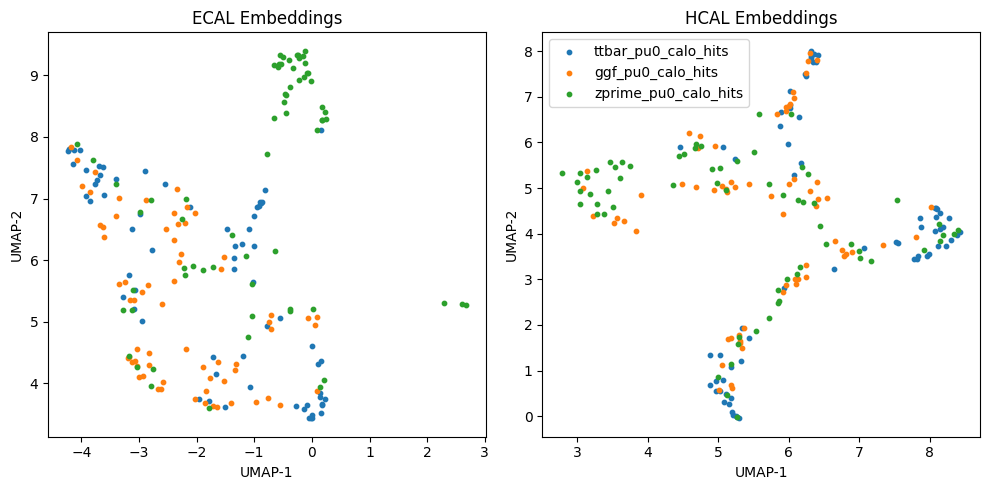

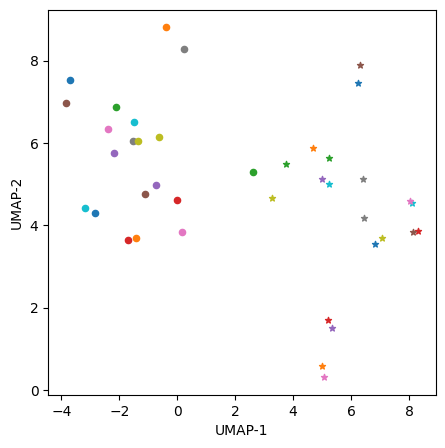

/global/homes/r/rmastand/.local/perlmutter/pytorch2.6.0/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


ttbar_pu0_calo_hits
ggf_pu0_calo_hits
zprime_pu0_calo_hits


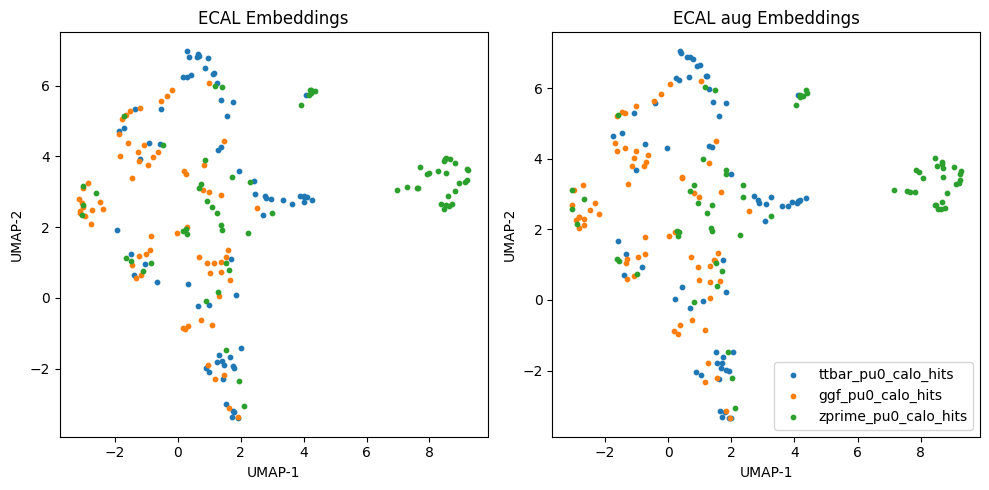

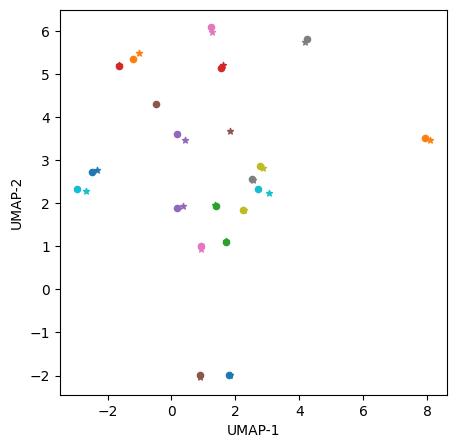

/global/homes/r/rmastand/.local/perlmutter/pytorch2.6.0/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


ttbar_pu0_calo_hits
ggf_pu0_calo_hits
zprime_pu0_calo_hits


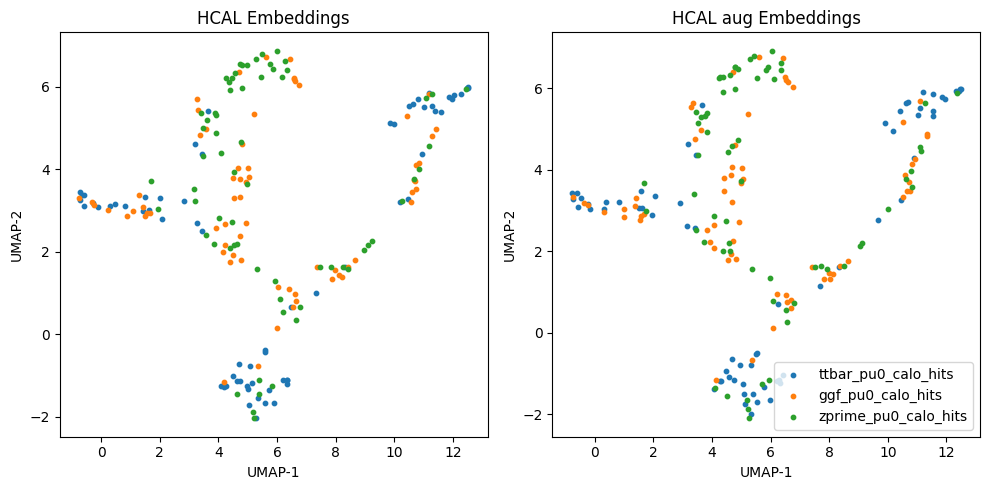

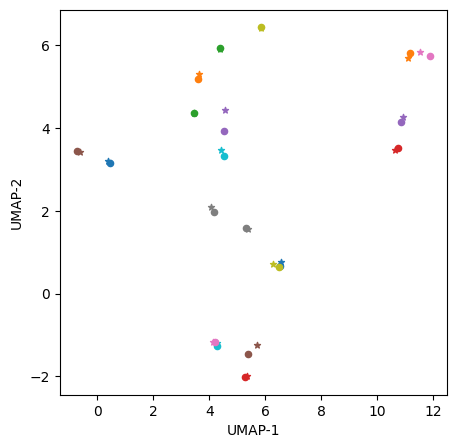

In [29]:
plot_umap_side_by_side(event_embeddings_orig_ECAL, event_embeddings_orig_HCAL, "ECAL", "HCAL")




plot_umap_side_by_side(event_embeddings_orig_ECAL, event_embeddings_aug_ECAL, "ECAL", "ECAL aug")


plot_umap_side_by_side(event_embeddings_orig_HCAL, event_embeddings_aug_HCAL, "HCAL", "HCAL aug")

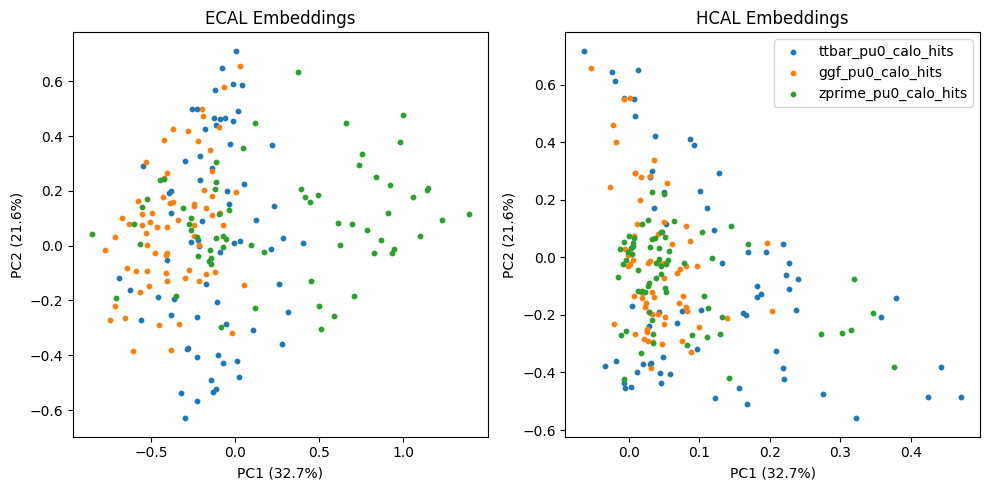

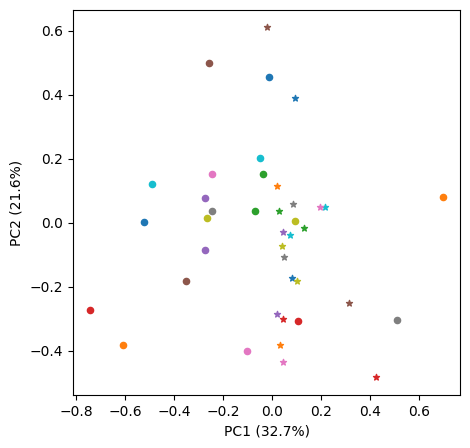

In [30]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

def plot_pca_side_by_side(embeddings_orig, embeddings_aug):
    # Move to CPU + convert to numpy
    if isinstance(embeddings_orig, torch.Tensor):
        embeddings_orig = embeddings_orig.detach().cpu().numpy()
    if isinstance(embeddings_aug, torch.Tensor):
        embeddings_aug = embeddings_aug.detach().cpu().numpy()

    # Fit PCA on combined data for consistent projection space
    combined = np.concatenate([embeddings_orig, embeddings_aug], axis=0)
    reducer = PCA(n_components=2)
    embedding_2d = reducer.fit_transform(combined)

    # Split back
    n = embeddings_orig.shape[0]
    emb_orig_2d = embedding_2d[:n]
    emb_aug_2d = embedding_2d[n:]

    # Plot side-by-side
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))

    axes[0].set_title("ECAL Embeddings")
    axes[0].set_xlabel(f"PC1 ({reducer.explained_variance_ratio_[0]*100:.1f}%)")
    axes[0].set_ylabel(f"PC2 ({reducer.explained_variance_ratio_[1]*100:.1f}%)")

    axes[1].set_title("HCAL Embeddings")
    axes[1].set_xlabel(f"PC1 ({reducer.explained_variance_ratio_[0]*100:.1f}%)")
    axes[1].set_ylabel(f"PC2 ({reducer.explained_variance_ratio_[1]*100:.1f}%)")

    for i, s in enumerate(subsets):
        mask = np.array(labels) == s
        axes[0].scatter(emb_orig_2d[:, 0][mask], emb_orig_2d[:, 1][mask], s=10, color=f"C{i}", label=s)
        axes[1].scatter(emb_aug_2d[:, 0][mask], emb_aug_2d[:, 1][mask], s=10, color=f"C{i}", label=s)

    plt.legend()
    plt.tight_layout()
    plt.show()

    # Plot first 20 sample pairs (circle = orig, star = aug)
    plt.figure(figsize=(5, 5))
    for i in range(20):
        plt.scatter(emb_orig_2d[i, 0], emb_orig_2d[i, 1], s=20, color=f"C{i}", marker="o")
        plt.scatter(emb_aug_2d[i, 0], emb_aug_2d[i, 1], s=20, color=f"C{i}", marker="*")
    plt.xlabel(f"PC1 ({reducer.explained_variance_ratio_[0]*100:.1f}%)")
    plt.ylabel(f"PC2 ({reducer.explained_variance_ratio_[1]*100:.1f}%)")
    plt.show()

plot_pca_side_by_side(event_embeddings_orig_ECAL, event_embeddings_orig_HCAL)

# Plot multiple events


In [16]:
position_lim = 0.5
e_lim = -1, 1


## x, y, z, e (1d)

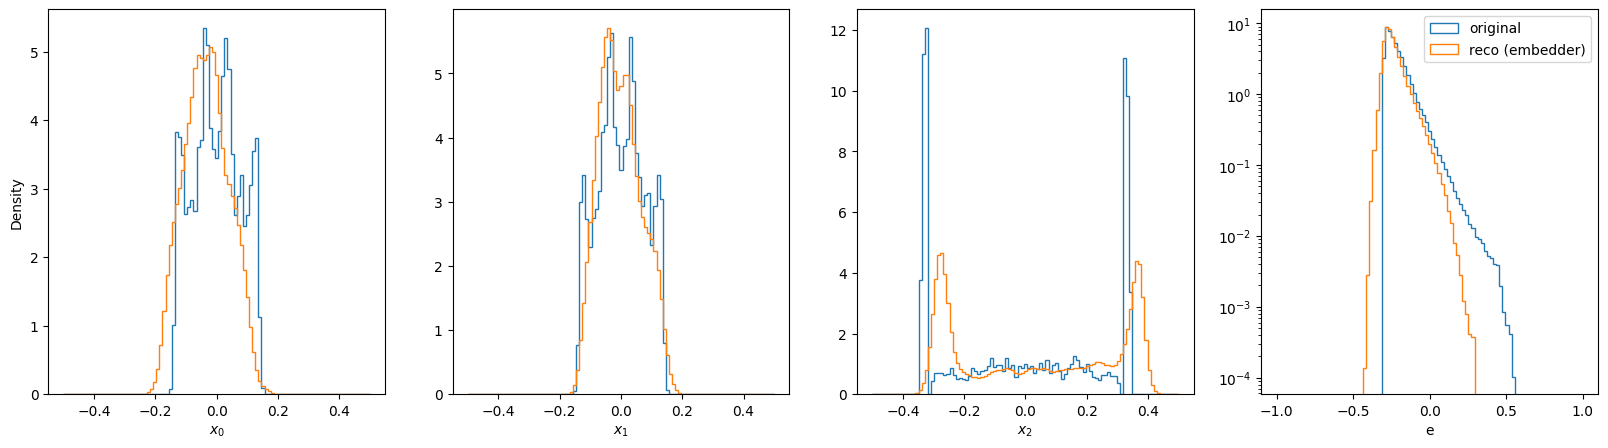

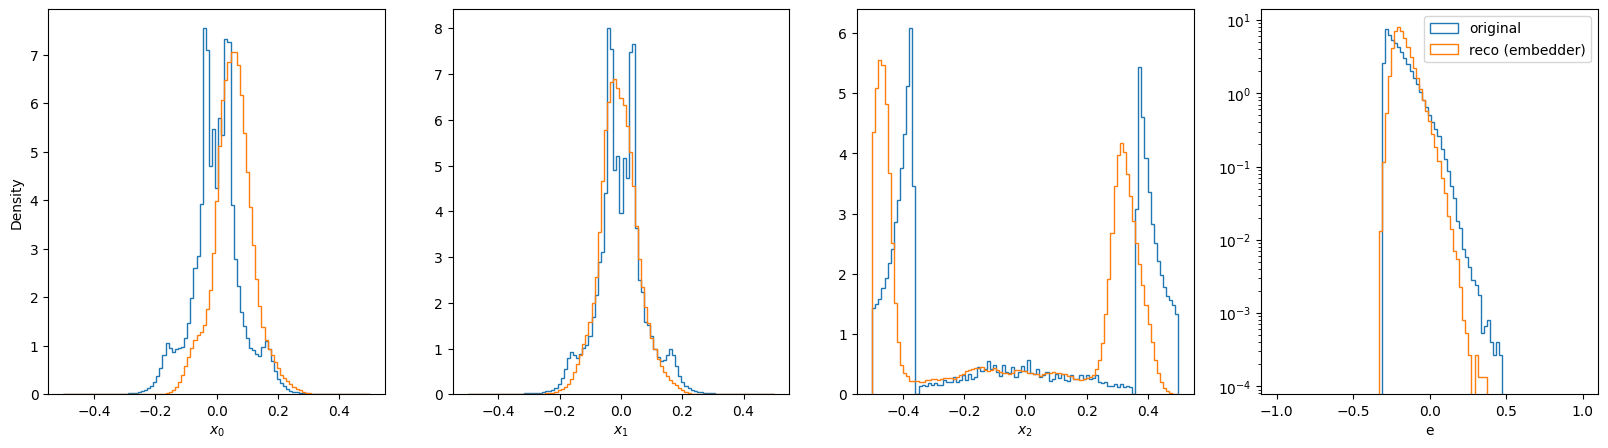

In [31]:
# calo

nbins = 100

fig, ax = plt.subplots(1, 4, figsize = (20, 5))

for i in range(3):

    ax[i].hist(ak.flatten(kinematic_features_truth_ECAL[i]), bins = np.linspace(-position_lim, position_lim, nbins), histtype = "step", label = "original", density=True)
    ax[i].hist(ak.flatten(kinematic_features_reco_ECAL[i]), bins = np.linspace(-position_lim, position_lim, nbins), histtype = "step", label = "reco (embedder)", density=True)

    ax[i].set_xlabel(f"$x_{i}$")

ax[3].hist(ak.flatten(kinematic_features_truth_ECAL[3]), bins = np.linspace(e_lim[0], e_lim[1], nbins), histtype = "step", label = "original", density=True)
ax[3].hist(ak.flatten(kinematic_features_reco_ECAL[3]), bins = np.linspace(e_lim[0], e_lim[1], nbins), histtype = "step", label = "reco (embedder)", density=True)
ax[3].set_xlabel("e")
ax[3].set_yscale("log")
ax[3].legend()

ax[0].set_ylabel("Density")

plt.show()

# calo

nbins = 100

fig, ax = plt.subplots(1, 4, figsize = (20, 5))

for i in range(3):

    ax[i].hist(ak.flatten(kinematic_features_truth_HCAL[i]), bins = np.linspace(-position_lim, position_lim, nbins), histtype = "step", label = "original", density=True)
    ax[i].hist(ak.flatten(kinematic_features_reco_HCAL[i]), bins = np.linspace(-position_lim, position_lim, nbins), histtype = "step", label = "reco (embedder)", density=True)

    ax[i].set_xlabel(f"$x_{i}$")

ax[3].hist(ak.flatten(kinematic_features_truth_HCAL[3]), bins = np.linspace(e_lim[0], e_lim[1], nbins), histtype = "step", label = "original", density=True)
ax[3].hist(ak.flatten(kinematic_features_reco_HCAL[3]), bins = np.linspace(e_lim[0], e_lim[1], nbins), histtype = "step", label = "reco (embedder)", density=True)
ax[3].set_xlabel("e")
ax[3].set_yscale("log")
ax[3].legend()

ax[0].set_ylabel("Density")

plt.show()

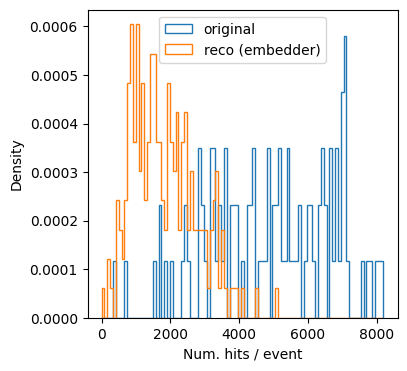

In [32]:
# number of hits

fig, ax = plt.subplots(1, 1, figsize = (4, 4))
ax.hist([len(event) for event in kinematic_features_truth_ECAL[0]], bins = np.linspace(0, 8192, nbins), histtype = "step", label = "original", density=True)
ax.hist([len(event) for event in kinematic_features_truth_HCAL[0]], bins = np.linspace(0, 8192, nbins), histtype = "step", label = "reco (embedder)", density=True)
ax.set_xlabel("Num. hits / event")
ax.set_ylabel("Density")
ax.legend()
plt.show()

# E resolution

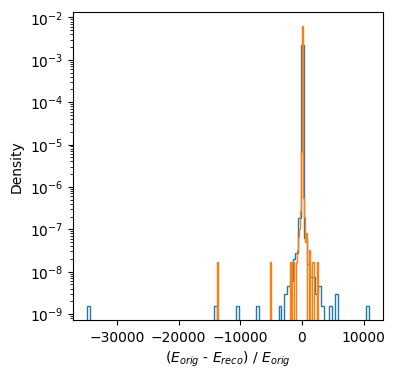

'\n\nfig, ax = plt.subplots(1, 1, figsize = (4, 4))\n\n\nunique_labels = [np.unique(l.to_numpy()) for l in hit_labels]\nhit_clusters_true, hit_clusters_reco = [], []\nfor event_i, hit_labels_event_i in enumerate(hit_labels):\n    for unique_label_event_i in unique_labels[event_i]:\n        mask = hit_labels_event_i == unique_label_event_i\n   \n        hit_clusters_true.append(np.sum(features_e[event_i][mask]))\n        hit_clusters_reco.append(np.sum(reco_e[event_i][mask]))\n\nax.hist((np.array(hit_clusters_true) - np.array(hit_clusters_reco))/np.array(hit_clusters_true), bins=nbins, density=True, histtype="step", linewidth=2)\nax.set_xlabel( "$E_{true} - E_{reco}$  / $E_{reco}$ per cluster")\nax.set_ylabel("Density")\nax.set_ylabel("Density")\nax.set_yscale("log")\n#ax.legend(loc="upper right")\n'

In [33]:
fig, ax = plt.subplots(1, 1, figsize = (4, 4))
ax.hist((ak.flatten(kinematic_features_truth_ECAL[3]) - ak.flatten(kinematic_features_reco_ECAL[3]))/ak.flatten(kinematic_features_truth_ECAL[3]), bins = nbins, histtype = "step", label = "ECAL", density=True)
ax.hist((ak.flatten(kinematic_features_truth_HCAL[3]) - ak.flatten(kinematic_features_reco_HCAL[3]))/ak.flatten(kinematic_features_truth_HCAL[3]), bins = nbins, histtype = "step", label = "HCAL", density=True)

ax.set_xlabel("($E_{orig}$ - $E_{reco}$) / $E_{orig}$")
ax.set_ylabel("Density")
ax.set_yscale("log")
plt.show()


"""

fig, ax = plt.subplots(1, 1, figsize = (4, 4))


unique_labels = [np.unique(l.to_numpy()) for l in hit_labels]
hit_clusters_true, hit_clusters_reco = [], []
for event_i, hit_labels_event_i in enumerate(hit_labels):
    for unique_label_event_i in unique_labels[event_i]:
        mask = hit_labels_event_i == unique_label_event_i
   
        hit_clusters_true.append(np.sum(features_e[event_i][mask]))
        hit_clusters_reco.append(np.sum(reco_e[event_i][mask]))

ax.hist((np.array(hit_clusters_true) - np.array(hit_clusters_reco))/np.array(hit_clusters_true), bins=nbins, density=True, histtype="step", linewidth=2)
ax.set_xlabel( "$E_{true} - E_{reco}$  / $E_{reco}$ per cluster")
ax.set_ylabel("Density")
ax.set_ylabel("Density")
ax.set_yscale("log")
#ax.legend(loc="upper right")
"""

# Plot single events

## x, y, z, e (1d)

In [34]:
# nbins = 100


# for event_i in range(10):

#     fig, ax = plt.subplots(1, 4, figsize = (20, 5))

#     for i in range(3):

#         ax[i].hist(kinematic_features_truth[i][event_i], bins = np.linspace(-position_lim, position_lim, nbins), histtype = "step", label = "original", density=True)
#         ax[i].hist(kinematic_features_reco[i][event_i], bins = np.linspace(-position_lim, position_lim, nbins), histtype = "step", label = "reco (embedder)", density=True)

#         ax[i].set_xlabel(f"$x_{i}$")
    

#     ax[3].hist(kinematic_features_truth[3][event_i], bins = np.linspace(e_lim[0], e_lim[1], nbins), histtype = "step", label = "original", density=True)
#     ax[3].hist(kinematic_features_reco[3][event_i], bins = np.linspace(e_lim[0], e_lim[1], nbins), histtype = "step", label = "reco (embedder)", density=True)

#     ax[3].set_xlabel("e")
#     ax[3].legend()

#     ax[0].set_ylabel("Density")

    
#     plt.show()


#     # fig, ax = plt.subplots(1, 1, figsize = (4, 4))
#     # ax.hist(tokens[event_i], bins = np.arange(-0.5, 522.5, 1), histtype = "step", label = "original")
#     # ax.legend()
#     # ax.set_xlabel("Token index")
#     # ax.set_ylabel("Density")
#     # plt.show()

## 2d positions

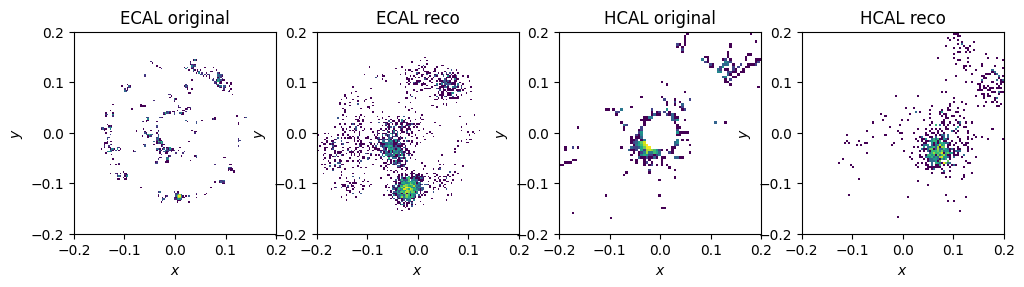

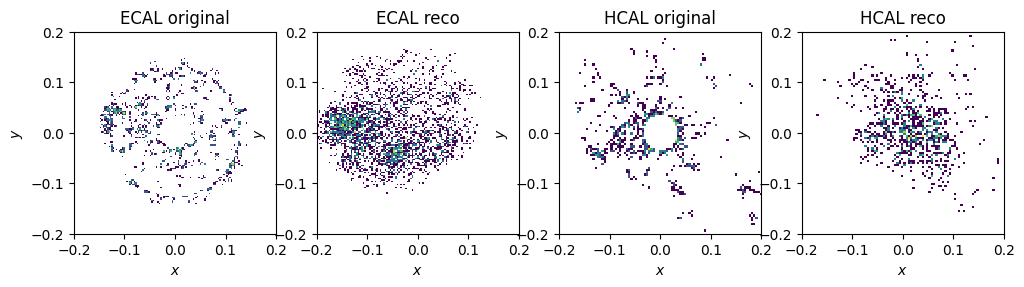

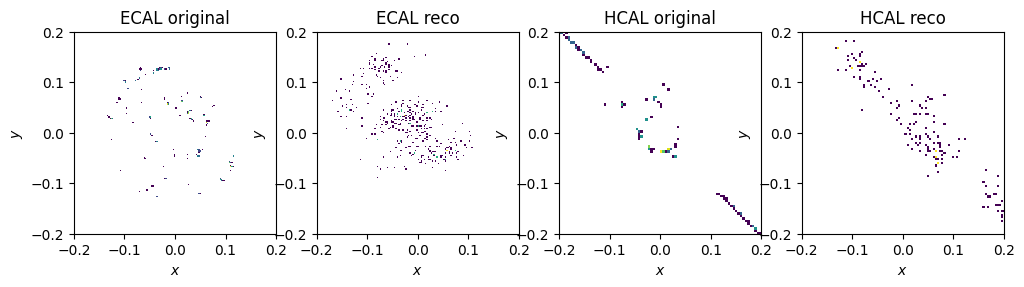

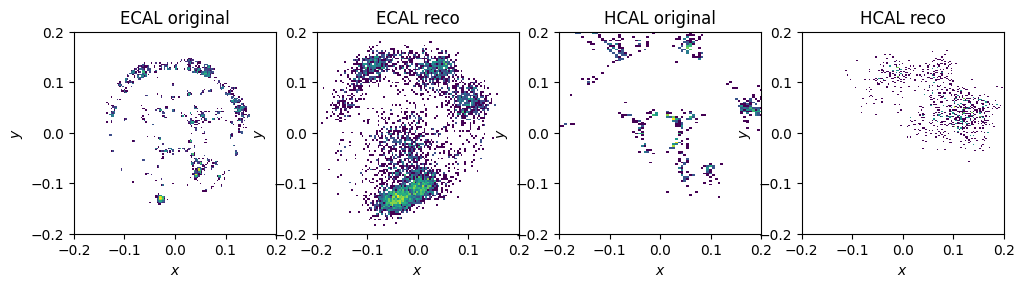

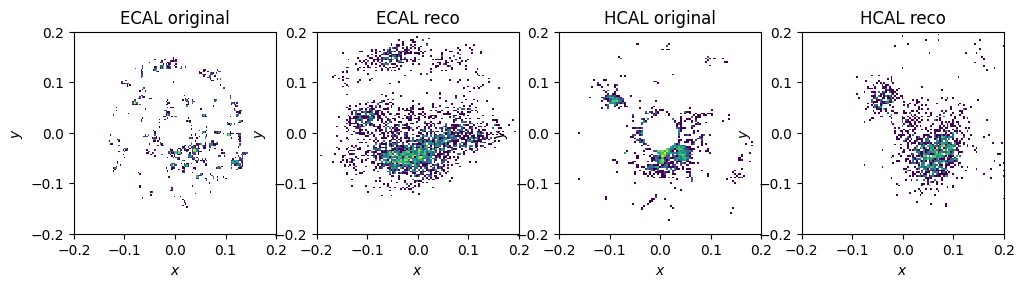

In [35]:
detector_index = 9

plot_lim = 0.2
s = 0.01

for i in range(5):

    fig, ax = plt.subplots(1, 4, figsize = (12, 5))

   

    
    ax[0].hist2d(np.asarray(kinematic_features_truth_ECAL[0][i]), np.asarray(kinematic_features_truth_ECAL[1][i]), bins = [100,100], norm="log")
    ax[0].set_xlabel(f"$x$")
    ax[0].set_ylabel(f"$y$")
    ax[0].set_title("ECAL original")
    
    ax[1].hist2d(np.asarray(kinematic_features_reco_ECAL[0][i]), np.asarray(kinematic_features_reco_ECAL[1][i]), bins = [100,100], norm="log")
    ax[1].set_xlabel(f"$x$")
    ax[1].set_ylabel(f"$y$")
    ax[1].set_title("ECAL reco")

    ax[2].hist2d(np.asarray(kinematic_features_truth_HCAL[0][i]), np.asarray(kinematic_features_truth_HCAL[1][i]), bins = [100,100], norm="log")
    ax[2].set_xlabel(f"$x$")
    ax[2].set_ylabel(f"$y$")
    ax[2].set_title("HCAL original")
    
    ax[3].hist2d(np.asarray(kinematic_features_reco_HCAL[0][i]), np.asarray(kinematic_features_reco_HCAL[1][i]), bins = [100,100], norm="log")
    ax[3].set_xlabel(f"$x$")
    ax[3].set_ylabel(f"$y$")
    ax[3].set_title("HCAL reco")

    for a in ax:
        a.set_box_aspect(1)   # <-- TRUE SQUARE SUBPLOT BOX
        a.set_xlim(-plot_lim, plot_lim)
        a.set_ylim(-plot_lim, plot_lim)


    
    plt.show()




/tmp/ipykernel_139248/4161669464.py:14: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  ax[0].hist2d(np.array(kinematic_features_truth_ECAL[2][i]), np.array(tmp_r), bins = [100,100], norm="log")
/tmp/ipykernel_139248/4161669464.py:22: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  ax[1].hist2d(np.array(kinematic_features_reco_ECAL[2][i]), np.array(tmp_r), bins = [100,100], norm="log")
/tmp/ipykernel_139248/4161669464.py:30: DeprecationWarning: __array__ implementation doesn't 

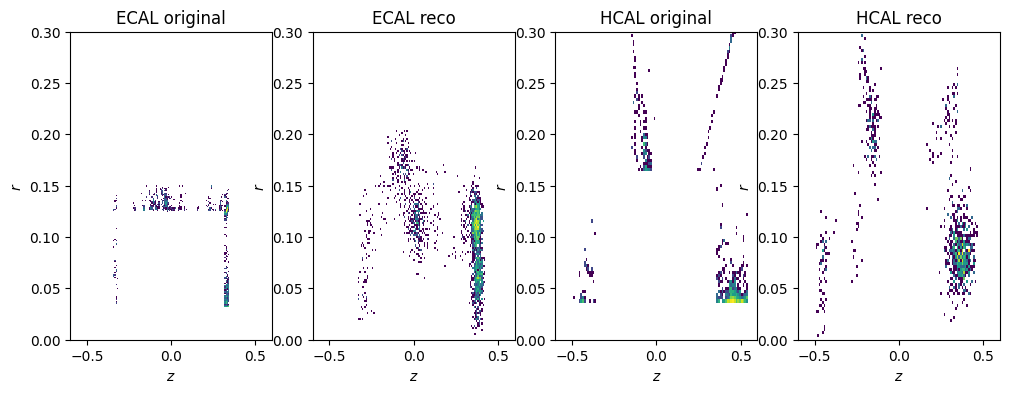

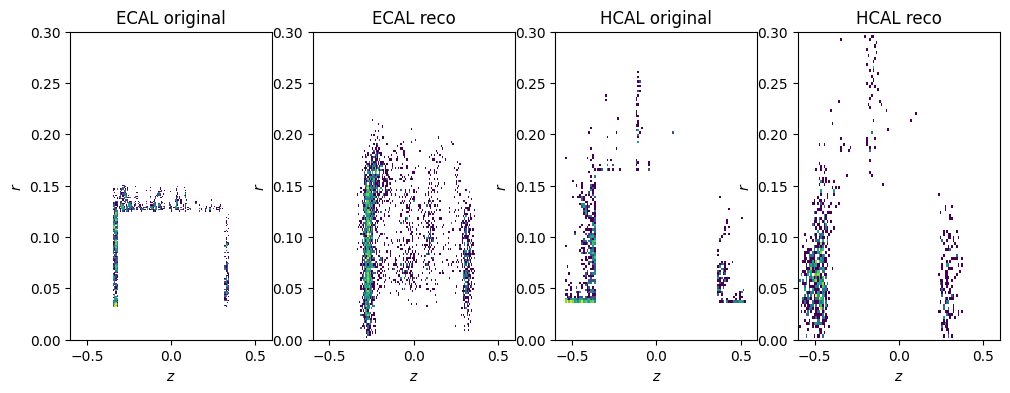

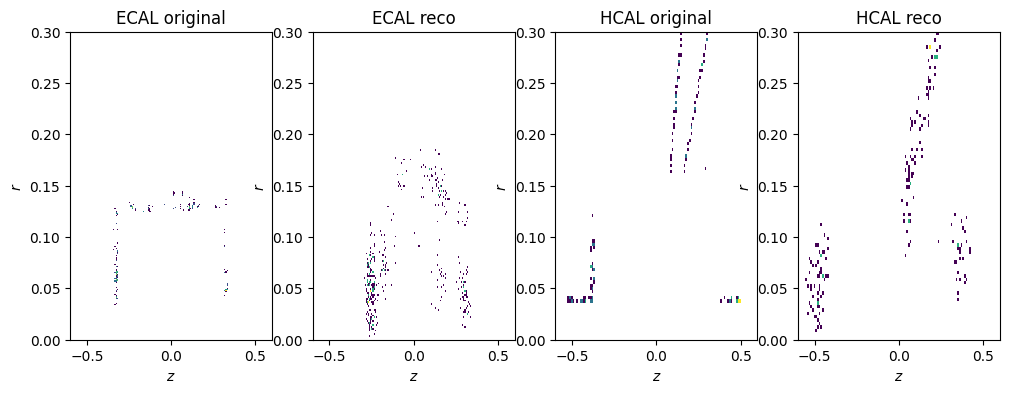

In [36]:
r_lim = 0., 0.3
z_lim = 0.6

for i in range(3):

    fig, ax = plt.subplots(1, 4, figsize = (12, 4))

    #for a in ax:
     #   a.set_box_aspect(1)   # <-- TRUE SQUARE SUBPLOT BOX
    #    a.set_xlim(-position_lim, position_lim)
     #   a.set_ylim(-position_lim, position_lim)

    tmp_r = np.sqrt(kinematic_features_truth_ECAL[0][i]**2 + kinematic_features_truth_ECAL[1][i]**2)
    ax[0].hist2d(np.array(kinematic_features_truth_ECAL[2][i]), np.array(tmp_r), bins = [100,100], norm="log")
    ax[0].set_xlabel(f"$z$")
    ax[0].set_ylabel(f"$r$")
    ax[0].set_xlim(-z_lim, z_lim)
    ax[0].set_ylim(r_lim)
    ax[0].set_title("ECAL original")

    tmp_r = np.sqrt(kinematic_features_reco_ECAL[0][i]**2 + kinematic_features_reco_ECAL[1][i]**2)
    ax[1].hist2d(np.array(kinematic_features_reco_ECAL[2][i]), np.array(tmp_r), bins = [100,100], norm="log")
    ax[1].set_xlabel(f"$z$")
    ax[1].set_ylabel(f"$r$")
    ax[1].set_xlim(-z_lim, z_lim)
    ax[1].set_ylim(r_lim)
    ax[1].set_title("ECAL reco")

    tmp_r = np.sqrt(kinematic_features_truth_HCAL[0][i]**2 + kinematic_features_truth_HCAL[1][i]**2)
    ax[2].hist2d(np.array(kinematic_features_truth_HCAL[2][i]), np.array(tmp_r), bins = [100,100], norm="log")
    ax[2].set_xlabel(f"$z$")
    ax[2].set_ylabel(f"$r$")
    ax[2].set_xlim(-z_lim, z_lim)
    ax[2].set_ylim(r_lim)
    ax[2].set_title("HCAL original")

    tmp_r = np.sqrt(kinematic_features_reco_HCAL[0][i]**2 + kinematic_features_reco_HCAL[1][i]**2)
    ax[3].hist2d(np.array(kinematic_features_reco_HCAL[2][i]), np.array(tmp_r), bins = [100,100], norm="log")
    ax[3].set_xlabel(f"$z$")
    ax[3].set_ylabel(f"$r$")
    ax[3].set_xlim(-z_lim, z_lim)
    ax[3].set_ylim(r_lim)
    ax[3].set_title("HCAL reco")

    


    
    plt.show()


